# Критерии остановки

*Общие закономерности*  
*Критерии остановки*  
*Выбор порогов*  
*Оценка длительности*  
*Минимальная длительность*

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "whitesmoke",
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titlepad": 20,
    "axes.titlelocation": "left",
    "lines.linewidth": 1.3,
    "legend.frameon": False,
    "figure.figsize": (10, 5),
    "figure.dpi": 200,
    "savefig.dpi": 200,
})
np.random.seed(7)

# Общие закономерности

По мере набора данных оценка эффекта уточняется.  
Для конверсий и средних стандартное отклонение разности снижается $\sim 1/\sqrt{N}$, где $N$ - количество наблюдений в группах.

При незначительной разнице между группами не нужно дожидаться 95% уверенности в одной из групп.  
Если эффект мал, эксперимент пора прекращать.

Оценка длительности должна учитывать последствия раскатки на всех пользователей.   
Чем больше влияние итогового решения, тем выше должна быть уверенность в нем.
  
Продолжение эксперимента - потери.  
Неоптимальная группа части пользователей и техдолг.

Ценность данных снижается с их накоплением.  
Первая тысяча точек имеет большую ценность чем дополнительная тысяча точек к уже собранному миллиону.  
Цена новых данных - цена продолжения эксперимента - не снижается.  

# Критерии остановки

Возможны разные критерии остановки. 

Без учета величины эффекта:
- Метрика одной группы лучше другой: $P(p_B > p_A) > c$ или $P(p_A > p_B) > c$ .
- Нет эффекта: $P(|p_B - p_A| < \delta) > c$
- Нет ухудшения: $P(p_B - p_A < -\delta) < c$

Ниже показаны графики условий.

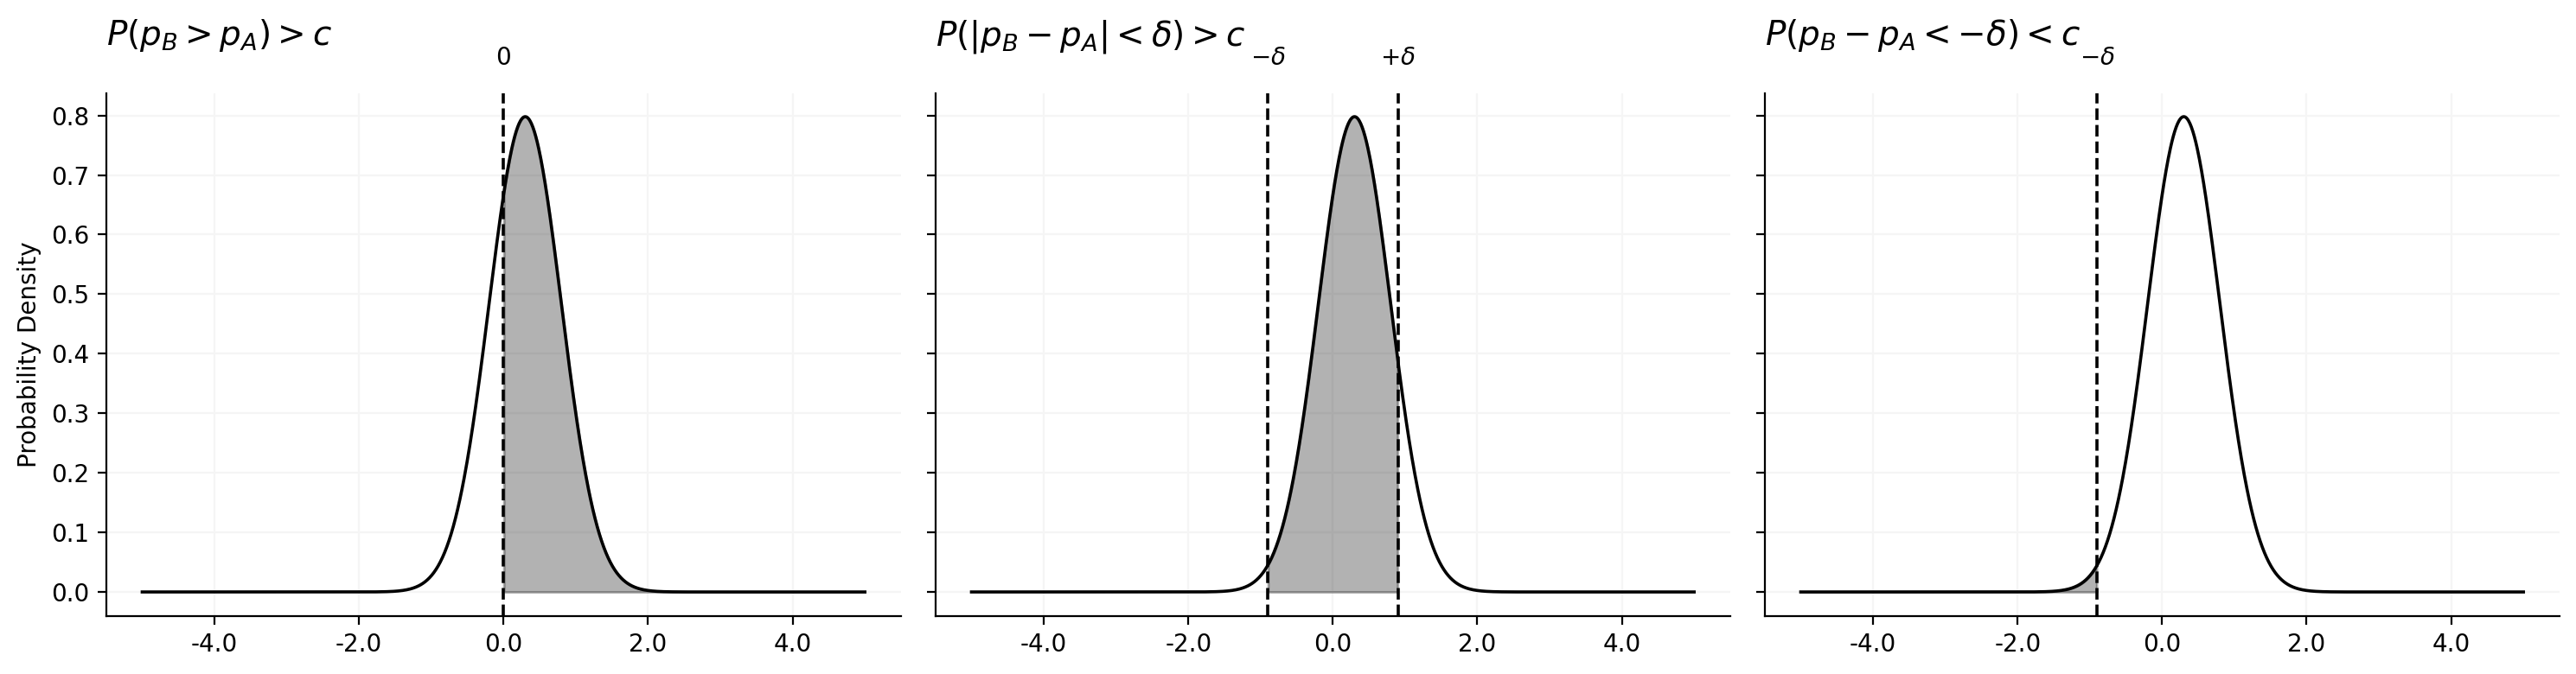

In [6]:
d = stats.norm(loc=0.3, scale=0.5)
delta = 0.9
x = np.linspace(-5, 5, 1000)
y = d.pdf(x)
ymax = y.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# P(pB > pA) > c
ax = axes[0]
ax.plot(x, y, color='black')
ax.axvline(0, linestyle='dashed', color='black')
ax.fill_between(x, y, where=(x > 0), alpha=0.3, color='black')
ax.text(0, 1.15 * y.max(), '0', ha='center', va='top')
ax.set_title(r'$P(p_B > p_A) > c$')
ax.set_ylabel('Probability Density')

# P(|pB - pA| < δ) > c
ax = axes[1]
ax.plot(x, y, color='black')
ax.axvline(-delta, linestyle='dashed', color='black')
ax.axvline(delta, linestyle='dashed', color='black')
ax.fill_between(x, y, where=(np.abs(x) < delta), alpha=0.3, color='black')
ax.text(-delta, 1.15 * ymax, r'$-\delta$', ha='center', va='top')
ax.text(delta, 1.15 * ymax, r'$+\delta$', ha='center', va='top')
ax.set_title(r'$P(|p_B - p_A| < \delta) > c$')

# P(pB - pA < -δ) < c
ax = axes[2]
ax.plot(x, y, color='black')
ax.axvline(-delta, linestyle='dashed', color='black')
ax.fill_between(x, y, where=(x < -delta), alpha=0.3, color='black')
ax.text(-delta, 1.15 * y.max(), r'$-\delta$', ha='center', va='top')
ax.set_title(r'$P(p_B - p_A < -\delta) < c$')

for ax in axes:
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.show()


Критерии остановки могут учитывать величину эффекта. Удобно определить ожидаемый выигрыш $E[G]$ и ожидаемый проигрыш $E[L]$ как средние положительной и отрицательной области распределения разности $P_{\Delta}(x)$. Ожидаемый проигрыш считается по модулю.

$$
E[G] = \int_0^{\infty} x P_{\Delta}(x) dx,
\quad
E[L] = \int_{-\infty}^0 |x| P_{\Delta}(x) dx,
$$

Возможные варианты остановки:
- Ожидаемый выигрыш в $k$ раз больше проигрыша: $E[G] > k E[L]$
- Нет эффекта: $E[L], E[G] < C$  
- Нет ухудшения: $E[L] < L$, $E[L] < E[G]$ (+низкая вероятность больших проигрышей в хвосте?)

Графики ниже.

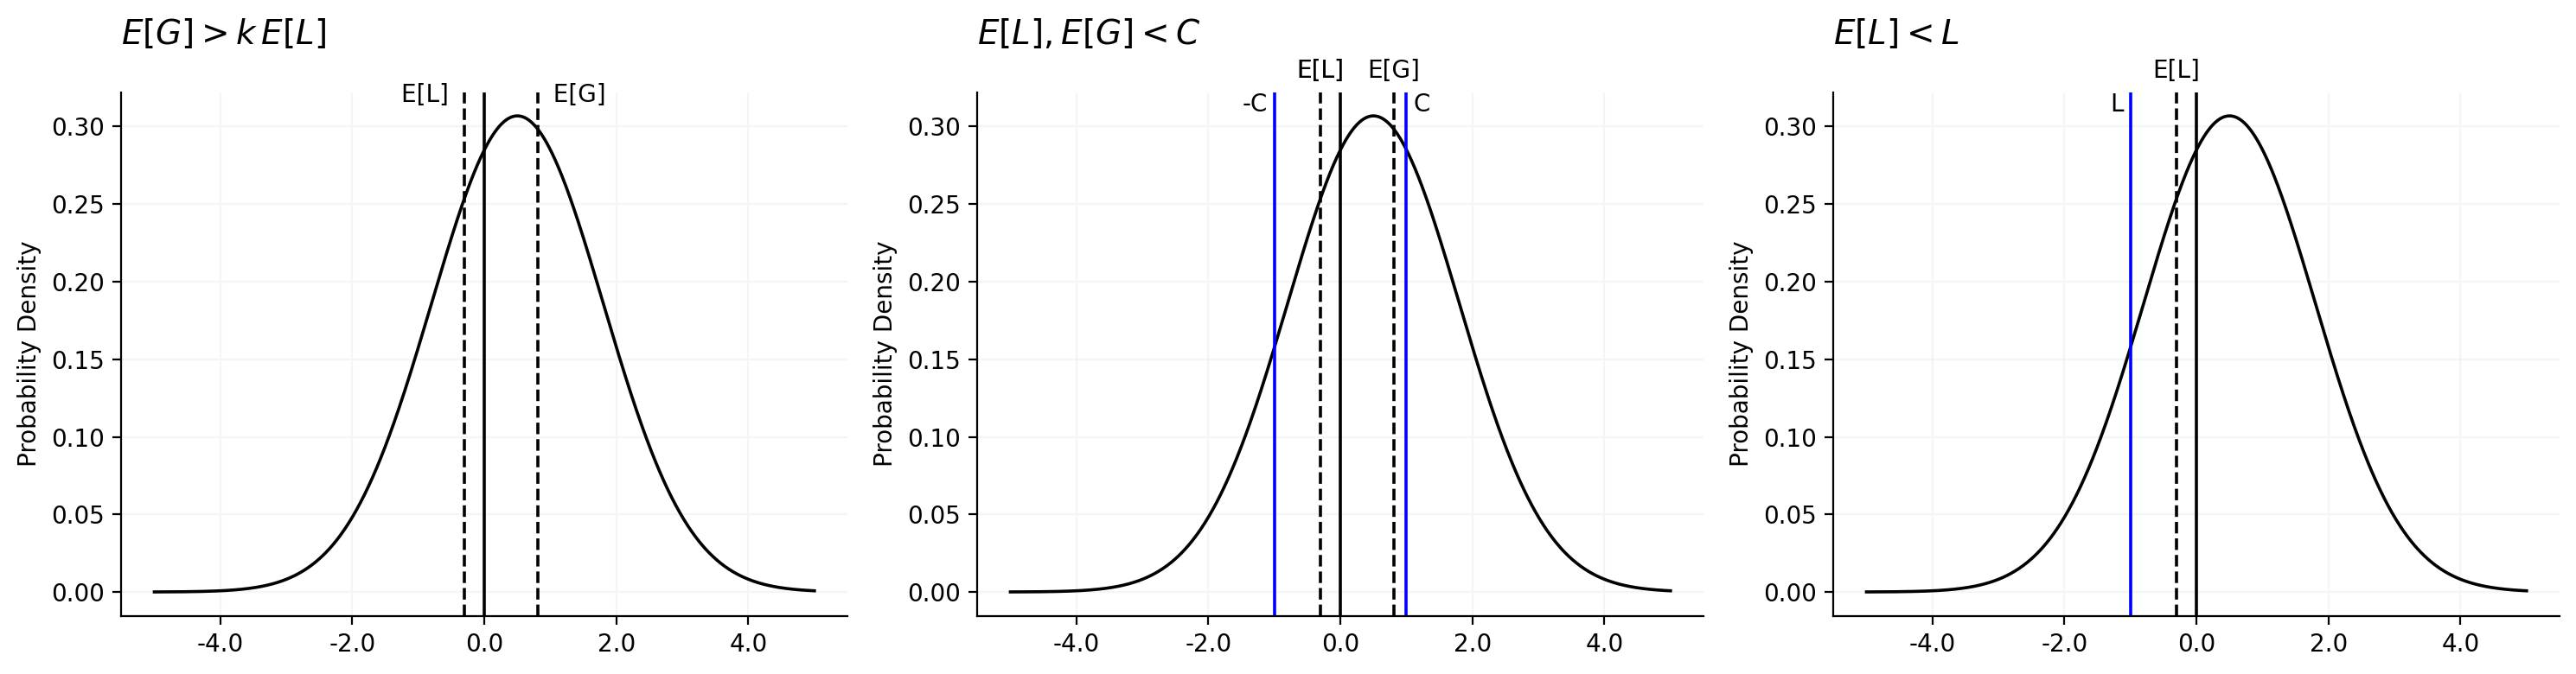

In [4]:
mu = 0.5
sigma = 1.3
d = stats.norm(loc=mu, scale=sigma)

zero_pos = (0 - mu) / sigma
tn_pos = stats.truncnorm(zero_pos, np.inf, loc=mu, scale=sigma)
P_pos = 1 - d.cdf(0)
E_pos = P_pos * tn_pos.mean()
tn_neg = stats.truncnorm(-np.inf, zero_pos, loc=mu, scale=sigma)
P_neg = d.cdf(0)
E_neg = P_neg * tn_neg.mean()

k = 2.0
C = 1
L = 1
delta = 0.1
c = 0.95

x = np.linspace(-5, 5, 1000)
pdf = d.pdf(x)
ymax = pdf.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# E[G] > k E[L]
ax = axes[0]
ax.plot(x, pdf, color='black')
ax.axvline(0, linestyle='solid', color='black')
ax.axvline(E_pos, linestyle='dashed', color='black')
ax.axvline(E_neg, linestyle='dashed', color='black')
ax.text(E_pos, 1.07*ymax, '  E[G]', ha='left', va='top')
ax.text(E_neg, 1.07*ymax, 'E[L]  ', ha='right', va='top')
#ax.text(0, 1.15*ymax, '0', ha='center', va='top')
ax.set_title(r'$E[G] > k\,E[L]$')
ax.set_ylabel('Probability Density')

#todo: use a narrow dist to illustrate small effect

# E[L], E[G] < C
ax = axes[1]
ax.plot(x, pdf, color='black')
ax.axvline(-C, linestyle='solid', color='blue')
ax.axvline(C, linestyle='solid', color='blue')
ax.axvline(E_pos, linestyle='dashed', color='black')
ax.axvline(E_neg, linestyle='dashed', color='black')
ax.axvline(0, linestyle='solid', color='black')
ax.text(E_neg, 1.12*ymax, 'E[L]', ha='center', va='top')
ax.text(E_pos, 1.12*ymax, 'E[G]', ha='center', va='top')
ax.text(E_neg, 1.12*ymax, 'E[L]', ha='center', va='top')
ax.text(-C - 0.1, 1.05*ymax, '-C', ha='right', va='top')
ax.text(C + 0.1, 1.05*ymax, 'C', ha='left', va='top')
ax.set_title(r'$E[L], E[G]<C$')
ax.set_ylabel('Probability Density')

# E[L] < L
ax = axes[2]
ax.plot(x, pdf, color='black')
ax.axvline(0, linestyle='solid', color='black')
ax.axvline(-L, linestyle='solid', color='blue')
ax.axvline(E_neg, linestyle='dashed', color='black')
ax.text(E_neg, 1.12*ymax, 'E[L]', ha='center', va='top')
ax.text(-L - 0.1, 1.05*ymax, 'L', ha='right', va='top')
ax.set_title(r'$E[L] < L$')
ax.set_ylabel('Probability Density')

for ax in axes:
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.show()


Еще один возможный критерий связан с ценностью новых данных. Эксперимент нет смысла продолжать, если снижение риска не оправдывает стоимость новых данных. Если обозначить новые данные $dN$ и их стоимость $Cost(dN)$, условие можно записать в виде:
- Снижение риска меньше стоимости данных: $E[L(N)] - E[L(N + dN)] < Cost(dN)$

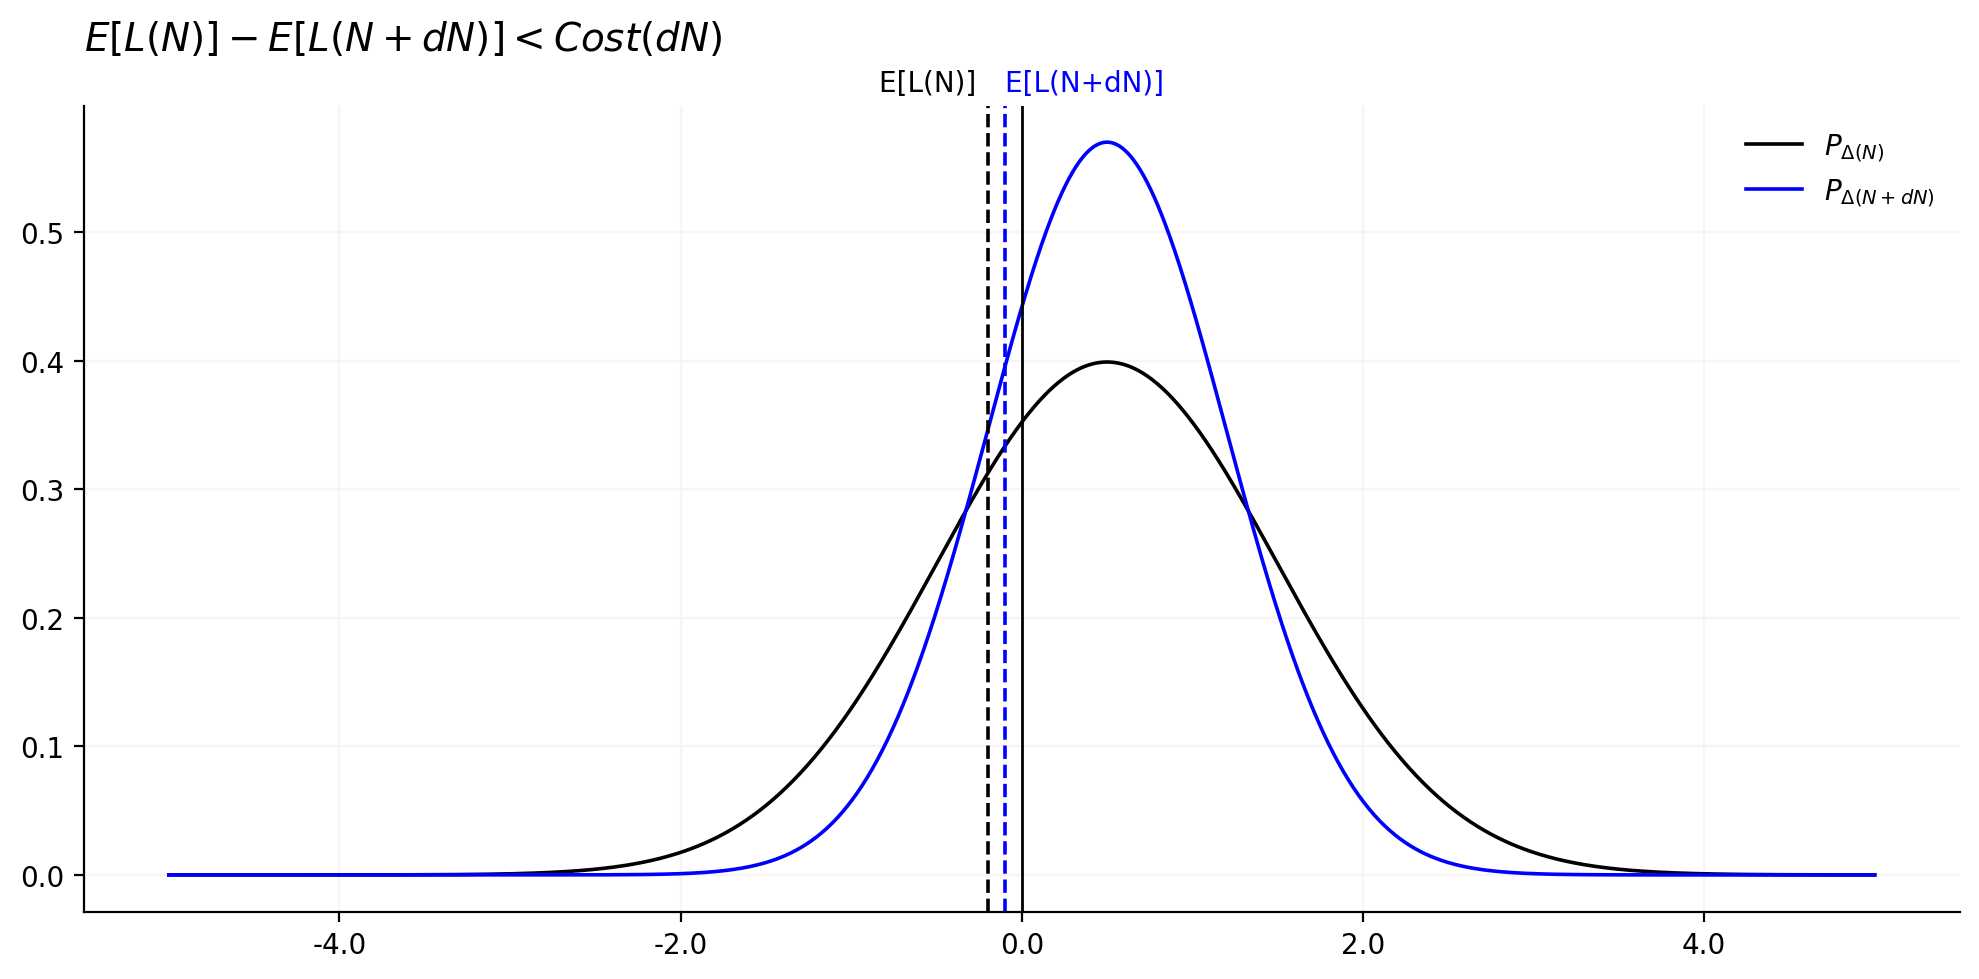

In [15]:
mu = 0.5
sigma1 = 1.0
sigma2 = 0.7

d1 = stats.norm(loc=mu, scale=sigma1)
d2 = stats.norm(loc=mu, scale=sigma2)
z1 = (0 - mu) / sigma1
tn1 = stats.truncnorm(-np.inf, z1, loc=mu, scale=sigma1)
en1 = d1.cdf(0) * tn1.mean()
z2 = (0 - mu) / sigma2
tn2 = stats.truncnorm(-np.inf, z2, loc=mu, scale=sigma2)
en2 = d2.cdf(0) * tn2.mean()

x = np.linspace(-5, 5, 1000)
y1 = d1.pdf(x)
y2 = d2.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y1, color='black', label=r'$P_{\Delta(N)}$')
ax.plot(x, y2, color='blue',  label=r'$P_{\Delta(N+dN)}$')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(en1, linestyle='dashed', color='black')
ax.axvline(en2, linestyle='dashed', color='blue')
ymax = max(y1.max(), y2.max())
ax.text(en1-0.02, 1.1 * ymax, 'E[L(N)] ', ha='right', va='top')
ax.text(en2, 1.1 * ymax, 'E[L(N+dN)] ', ha='left', va='top', color='blue')
ax.set_title(r'$E[L(N)] - E[L(N+dN)] < Cost(dN)$')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.legend()

plt.tight_layout()
plt.show()

Для критериев нужно задать пороги.  
Также удобно оценить длительность эксперимента до запуска.  

# Выбор порогов

Пороги задают баланс между количеством изменений и количеством ухудшений.  
Больше точность - дольше эксперименты.  


<center>
<img src="../figs/bayes_better_worse_guess.png" alt="bayes_better_worse_guess" width="500"/>
    поменять $p \to c$
</center>

$N$ - всего эксп.  
$H$ - вероятность улучшения (качество гипотезы)  
$с$ - вероятность выбрать лучшую группу  

$N H с$ - улучшения  
$N (1-H) (1-с)$ - ухудшения

Улучшений в $k$ раз больше ухудшений:
$$
N H c > k N (1-H) (1-c)
\\
c > \frac{k (1-H)}{H + k (1-H)}
\\
k=1: \quad c > 1 - H
$$

In [5]:
k=5
H=0.2
k*(1-H) / (H + k * (1-H))

0.9523809523809523

Как выбрать пороги.  
Пороги - это соотношение количество релизов-точность.   

Стоит целиться в значимые улучшения.  
Сильный эффект. Видно быстро.  
Точность менее важна.  
Нужен контроль ошибок.  

Для компаний ранней стадии - быстрые значимые улучшения.   
Для сложившегося продукта? Очевидные идеи заканчиваются. Значимые изменения в отдельных сегментах?

Нужна оценка длительности до порогов?  
Тогда будет виднее баланс скорость-точность.  

# Оценка длительности

Пусть пороги заданы.  
Нужно оценить длительность экспериментов.

Набор данных и изменение оценок вероятностей - случайный процесс.  
Нельзя заранее точно сказать, сколько времени понадобится для завершения эксперимента.  
Построить распределение оценок длительности.  
В этом распределении выделить среднее или квантиль.  

Еще одна проблема - преждевременное прекращение экспериментов.  
Это ведет к отклонениям от заявленной точности.  
Нужно задавать минимальный размер выборки.  

Распределение длительности - первое касание стенки в броуновском движении + дрифт?  
https://en.wikipedia.org/wiki/Inverse_Gaussian_distribution  
Это для фиксированной стенки.  
Здесь стенка сужается со временем.  
Можно ожидать меньшего хвоста и меньших средних.  

Дрифт - величина эффекта.

Notation:
$$
\begin{aligned}
& \Delta = B-A \quad \text{(true lift)} \\
& \hat\mu = \text{posterior mean of } \Delta \\
& \hat\sigma^2 = \text{posterior variance of } \Delta \\
& p = \text{Bernoulli probability of success} \\
& N = \text{number of observations per group} \\
& c = \text{stopping probability threshold} \\
& \delta = \text{equivalence / minimum gain threshold} \\
& k = \text{gain/loss ratio threshold} \\
& L = \text{maximum expected loss allowed}
\end{aligned}
$$

Оценка длительности (конверсии)

$$
P(p_B - p_A > 0) > c,
\qquad \Delta = p_B - p_A
\\
\Delta \mid \text{data} \sim \mathcal N(\hat\mu, \hat\sigma^2)
\\
P(\Delta > 0)
= 1 - \Phi\!\left(\frac{0-\hat\mu}{\hat\sigma}\right)
= c
\quad \Rightarrow \quad
\frac{\hat\mu}{\hat\sigma} = \Phi^{-1}(c)
\\
\hat\sigma^2
\approx
\frac{p_A(1-p_A)}{N}
+
\frac{p_B(1-p_B)}{N}
\approx
\frac{2p(1-p)}{N}
\\
\hat\mu
=
\Phi^{-1}(c)\sqrt{\frac{2p(1-p)}{N}}
\\
N
\approx
\frac{2p(1-p)\,(\Phi^{-1}(c))^2}{\hat\mu^2}
$$

Probability threshold: $P(B>A) > c$
$$
P(\Delta > 0) = 1 - \Phi\left(\frac{0 - \hat\mu}{\hat\sigma}\right) = c
\quad \Rightarrow \quad
\hat\sigma = \frac{\hat\mu}{\Phi^{-1}(c)}
\quad \Rightarrow \quad
N \approx \frac{p(1-p)}{(\hat\mu / \Phi^{-1}(c))^2}
$$

No-harm threshold: $P(B-A < -\delta) < c$
$$
\\
P(\Delta < -\delta) = \Phi\left(\frac{-\delta - \hat\mu}{\hat\sigma}\right) < c
\quad \Rightarrow \quad
\hat\sigma = \frac{\delta + \hat\mu}{\Phi^{-1}(c)}
\quad \Rightarrow \quad
N \approx \frac{p(1-p)}{((\delta+\hat\mu)/\Phi^{-1}(c))^2}
$$

No-effect / equivalence: $P(|B-A| < \delta) > c$
$$
P(|\Delta| < \delta) \approx 2\Phi\left(\frac{\delta}{\hat\sigma}\right)-1 = c
\quad \Rightarrow \quad
\hat\sigma = \frac{\delta}{\Phi^{-1}((c+1)/2)}
\quad \Rightarrow \quad
N \approx \frac{p(1-p)}{(\delta / \Phi^{-1}((c+1)/2))^2}
$$

Utility-based: $E[\text{Gain}] > k E[\text{Loss}]$
$$
\text{Ship if } E[\text{Gain}] - k E[\text{Loss}] > 0
\quad \Rightarrow \quad
N \approx \frac{\mathrm{Var}(\text{Gain}-k\text{Loss})}{(E[\text{Gain}]-k E[\text{Loss}])^2}
$$

Utility-based: $E[\text{Loss}] < L$
$$
\\
\text{Ship if } E[\text{Loss}] < L
\quad \Rightarrow \quad
N \approx \frac{\mathrm{Var}(\text{Loss})}{(L - E[\text{Loss}])^2}
$$

Minimum gain: $P(\text{Gain} < \delta) < c$
$$
P(\Delta < \delta) = \Phi\left(\frac{\delta - \hat\mu}{\hat\sigma}\right) < c
\quad \Rightarrow \quad
\hat\sigma = \frac{\hat\mu - \delta}{\Phi^{-1}(c)}
\quad \Rightarrow \quad
N \approx \frac{\hat\sigma_0^2 (\Phi^{-1}(c))^2}{(\hat\mu-\delta)^2}
$$

$$
\text{Summary Table of Required Sample Sizes:}
\\
\begin{array}{|l|l|}
\hline
\text{Stopping Condition} & N \text{ (observations per group)} \\
\hline
P(B>A) > c & \frac{p(1-p)}{(\hat\mu / \Phi^{-1}(c))^2} \\
P(B-A < -\delta) < c & \frac{p(1-p)}{((\delta+\hat\mu)/\Phi^{-1}(c))^2} \\
P(|B-A|<\delta) > c & \frac{p(1-p)}{(\delta / \Phi^{-1}((c+1)/2))^2} \\
E[\text{Gain}] > k E[\text{Loss}] & \frac{\mathrm{Var}(\text{Gain}-k\text{Loss})}{(E[\text{Gain}]-k E[\text{Loss}])^2} \\
E[\text{Loss}] < L & \frac{\mathrm{Var}(\text{Loss})}{(L - E[\text{Loss}])^2} \\
P(\text{Gain}<\delta)<c & \frac{\hat\sigma^2 (\Phi^{-1}(c))^2}{(\hat\mu-\delta)^2} \\
\hline
\end{array}
$$


# Минимальная длительность

$$
\frac{p_B - p_A}{p_A} < 0.03
$$

Относительная разность меньше 3% с вероятностью 95% .
$$
P\left(\frac{p_B - p_A}{p_A} < 0.03\right) > 95 \%
$$

$$
P\left(\frac{p_B}{p_A} < 1.03\right) > 95 \%
$$

Нужно учесть знак.

$$
\frac{|p_B - p_A|}{p_A} < 0.03
$$

Начать с абсолютной разности.

$$
P(|p_B - p_A| < c)
\\
P_{p_B - p_A}(x) 
\approx \mbox{Norm}\left(x; \mu_B - \mu_A, \sigma_A^2 + \sigma_B^2\right)
\\
\\
\begin{split}
P(|p_B - p_A| < c) & = P(p_B - p_A < c) + P(p_B - p_A > 1 - c) 
\\
& = F_{p_B - p_A}(c) + 1 - F_{p_B - p_A}(1 - c)
\\
& = 1 - 2 F_{p_B - p_A}(c)
\end{split}
$$

Условие остановки: либо одна группа лучше другой $P(B>A) > 95\%$, либо разница несущественна $P(|B-A| < c) > 95\%$.

То же для относительной разности.

$$
P(\frac{|p_B - p_A|}{p_A} < c)
$$

Следующий вопрос - как выбрать $c$ и $95\%$?  
Здесь понадобится оценка последствий.  

Вероятность одной группы лучше другой связана с оценкой эффекта?

Нарисовать картинку с динамикой.  
Разность по мере набора данных.  
Полоса [-c, c].

In [25]:
def posterior_dist_binom(ns, ntotal, a_prior=1, b_prior=1):
    a = a_prior + ns
    b = b_prior + ntotal - ns 
    return stats.beta(a=a, b=b)

def prob_pb_gt_pa(post_dist_A, post_dist_B, post_samp=100_000):
    sa = post_dist_A.rvs(size=post_samp)
    sb = post_dist_B.rvs(size=post_samp)
    b_gt_a = np.sum(sb > sa)
    return b_gt_a / post_samp

cmp = pd.DataFrame(columns=['A', 'B', 'best_exact', 'exp_samp_size', 'A_exp', 'B_exp', 'best_exp', 'p_best'])

p = 0.1
nexps = 10000
cmp['A'] = [p] * nexps
cmp['B'] = p * 1.03 #(1 + stats.uniform.rvs(loc=-0.05, scale=0.1, size=nexps))
cmp['best_exact'] = cmp.apply(lambda r: 'B' if r['B'] > r['A'] else 'A', axis=1)

n_samp_max = 30_000_000
n_samp_step = 1000
prob_stop = 0.95

for i in range(nexps):
    pA = cmp.at[i, 'A']
    pB = cmp.at[i, 'B']
    exact_dist_A = stats.bernoulli(p=pA)
    exact_dist_B = stats.bernoulli(p=pB)
    n_samp_total = 0
    ns_A = 0
    ns_B = 0
    while n_samp_total < n_samp_max:
        dA = exact_dist_A.rvs(n_samp_step)
        dB = exact_dist_B.rvs(n_samp_step)
        n_samp_total += n_samp_step
        ns_A = ns_A + np.sum(dA)
        ns_B = ns_B + np.sum(dB)
        post_dist_A = posterior_dist_binom(ns=ns_A, ntotal=n_samp_total)
        post_dist_B = posterior_dist_binom(ns=ns_B, ntotal=n_samp_total)
        pb_gt_pa = prob_pb_gt_pa(post_dist_A, post_dist_B)
        best_gr = 'B' if pb_gt_pa >= prob_stop else 'A' if (1 - pb_gt_pa) >= prob_stop else None
        if best_gr:
            cmp.at[i, 'A_exp'] = post_dist_A.mean()
            cmp.at[i, 'B_exp'] = post_dist_B.mean()
            cmp.at[i, 'exp_samp_size'] = n_samp_total
            cmp.at[i, 'best_exp'] = best_gr
            cmp.at[i, 'p_best'] = max(pb_gt_pa, 1 - pb_gt_pa)
            break
    if i % 500 == 0:
        print(f'done {i}: nsamp {n_samp_total}, best_gr {best_gr}, P(b>a) {pb_gt_pa}')

cmp['correct'] = cmp['best_exact'] == cmp['best_exp']
display(cmp.head(30))
cor_guess = np.sum(cmp['correct'])
print(f"Nexp: {nexps}, Correct Guesses: {cor_guess}, Accuracy: {cor_guess / nexps}")

done 0: nsamp 1000, best_gr B, P(b>a) 0.99889
done 500: nsamp 5000, best_gr B, P(b>a) 0.97727
done 1000: nsamp 8000, best_gr B, P(b>a) 0.97316
done 1500: nsamp 19000, best_gr B, P(b>a) 0.95228
done 2000: nsamp 11000, best_gr B, P(b>a) 0.97603
done 2500: nsamp 26000, best_gr B, P(b>a) 0.95417
done 3000: nsamp 29000, best_gr B, P(b>a) 0.9601
done 3500: nsamp 2000, best_gr A, P(b>a) 0.04818
done 4000: nsamp 20000, best_gr B, P(b>a) 0.97763
done 4500: nsamp 4000, best_gr B, P(b>a) 0.99655
done 5000: nsamp 11000, best_gr B, P(b>a) 0.95966
done 5500: nsamp 7000, best_gr B, P(b>a) 0.98051
done 6000: nsamp 13000, best_gr B, P(b>a) 0.95622
done 6500: nsamp 14000, best_gr B, P(b>a) 0.96218
done 7000: nsamp 14000, best_gr B, P(b>a) 0.969
done 7500: nsamp 2000, best_gr A, P(b>a) 0.04306
done 8000: nsamp 10000, best_gr B, P(b>a) 0.96988
done 8500: nsamp 2000, best_gr B, P(b>a) 0.96799
done 9000: nsamp 2000, best_gr B, P(b>a) 0.95257
done 9500: nsamp 25000, best_gr B, P(b>a) 0.96737


,A,B,best_exact,exp_samp_size,A_exp,B_exp,best_exp,p_best,correct
0,0.1,0.103,B,1000,0.087824,0.129741,B,0.99889,True
1,0.1,0.103,B,4000,0.094953,0.107196,B,0.96639,True
2,0.1,0.103,B,1000,0.10479,0.131737,B,0.96951,True
3,0.1,0.103,B,18000,0.100489,0.105822,B,0.9521,True
4,0.1,0.103,B,44000,0.100268,0.10395,B,0.96489,True
5,0.1,0.103,B,18000,0.098434,0.103766,B,0.95306,True
6,0.1,0.103,B,70000,0.09984,0.102526,B,0.95229,True
7,0.1,0.103,B,4000,0.0992,0.110945,B,0.95674,True
8,0.1,0.103,B,80000,0.10096,0.103485,B,0.95194,True
9,0.1,0.103,B,12000,0.095567,0.103316,B,0.97739,True


Nexp: 10000, Correct Guesses: 9104, Accuracy: 0.9104


In [26]:
z_c = stats.norm.ppf(prob_stop)
var = pA * (1 - pA) + pB * (1 - pB)
delta = 1.03 * p - p # todo: 1.03
n_est = (var * z_c**2) / (delta**2)

n_est

54829.64179287952

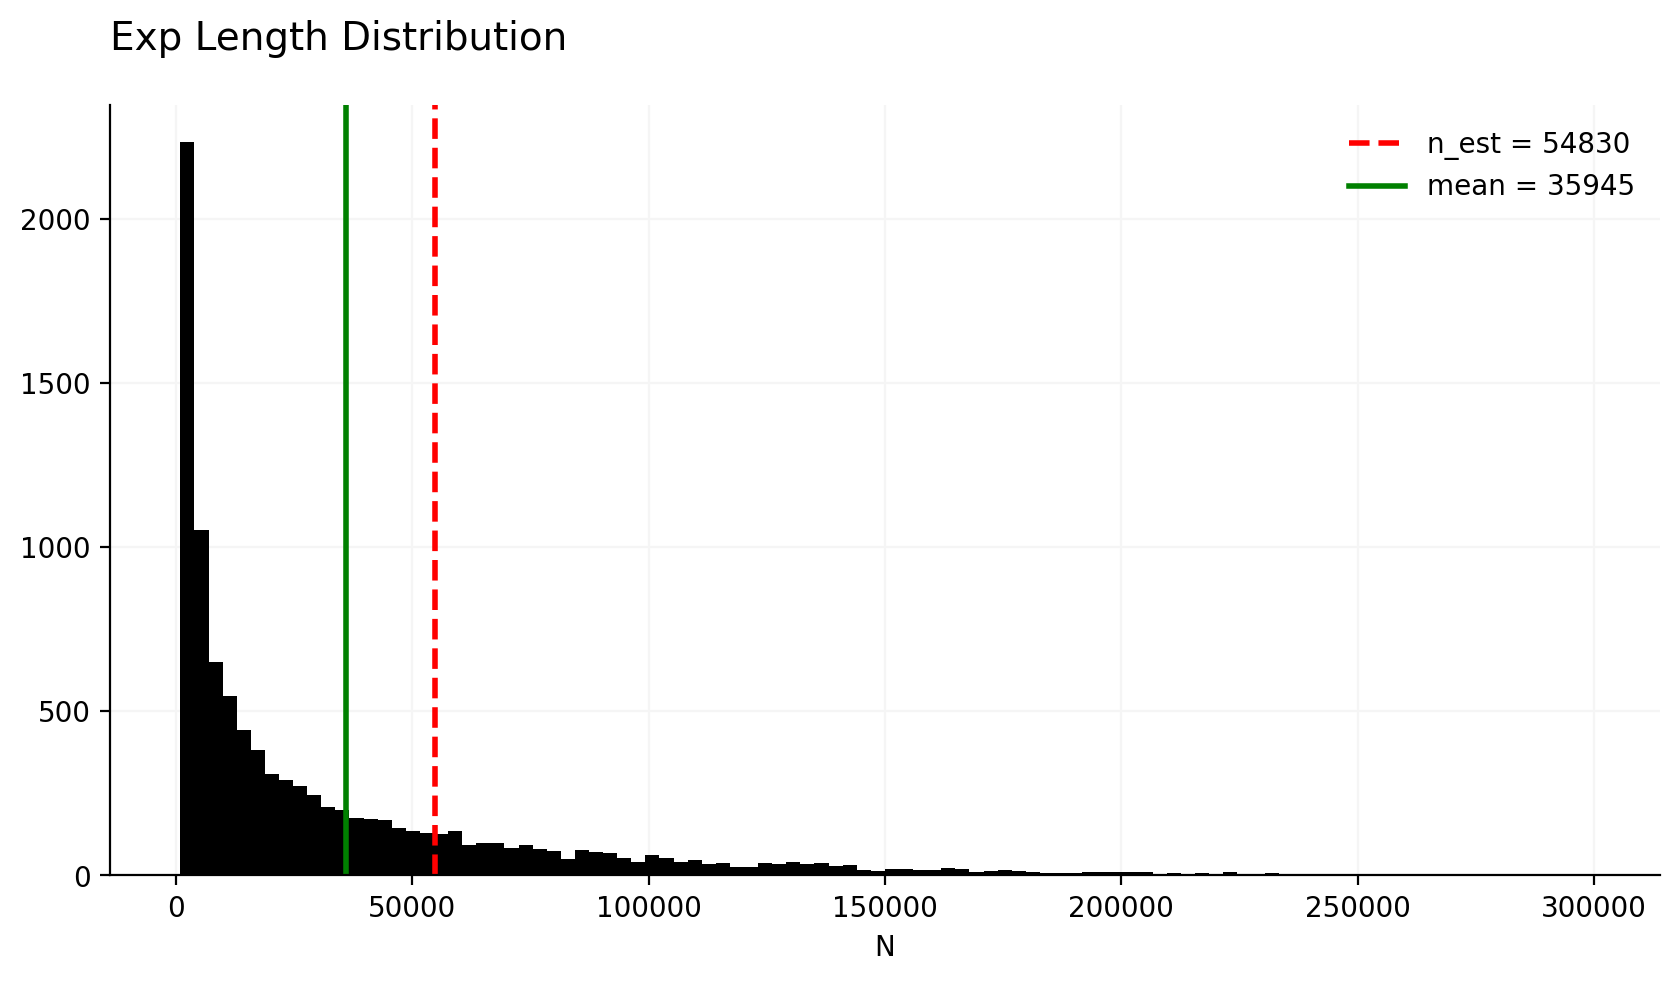

In [30]:


col = cmp["exp_samp_size"].dropna()
col_mean = col.mean()
col = col[col < 300000]

plt.figure(figsize=(10, 5))
plt.hist(col, bins=100, color="black")

# y to 1
# counts, bins = np.histogram(col, bins=50)
# probs = counts / counts.sum()
# plt.figure(figsize=(10, 5))
# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# plt.bar(bin_centers, probs, width=bins[1] - bins[0], color="black")

plt.axvline(n_est, color="red", linestyle="--", linewidth=2, label=f"n_est = {n_est:.0f}")
plt.axvline(col_mean, color="green", linestyle="-", linewidth=2, label=f"mean = {col_mean:.0f}")

plt.xlabel("N")
plt.title("Exp Length Distribution")
plt.legend()

plt.show()

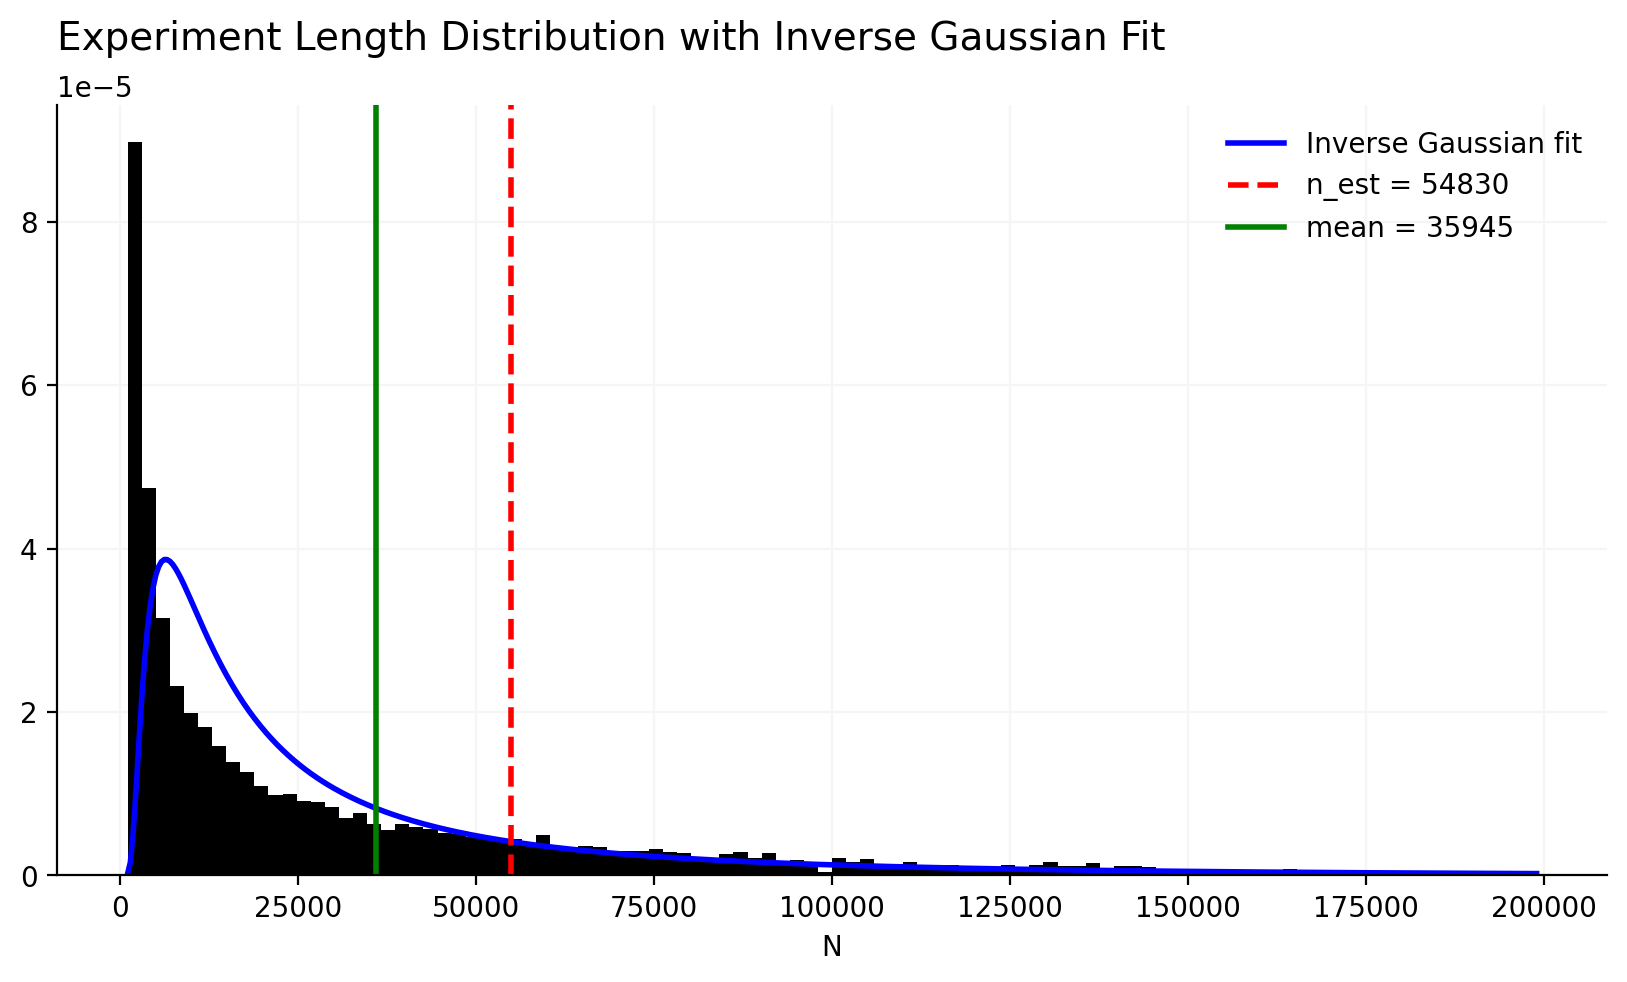

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, invgauss

col = cmp["exp_samp_size"].dropna()
col_mean = col.mean()
col_var = col.var()
col = col[col < 200000]

# --- theoretical estimate ---
z_c = norm.ppf(prob_stop)
var = pA * (1 - pA) + pB * (1 - pB)
n_est = (var * z_c**2) / (delta**2)

# --- fit inverse gaussian parameters ---
mu = col_mean
lam = (mu**3) / col_var

# scipy parameterization: invgauss(mu = shape)
# where shape = mu / lambda
shape = mu / lam

x = np.linspace(col.min(), col.max(), 500)
pdf = invgauss.pdf(x, shape, scale=lam)

# --- plot histogram (probability mass) ---
plt.figure(figsize=(10, 5))
plt.hist(col, bins=100, density=True, color="black")

# --- inverse gaussian fit ---
plt.plot(x, pdf, color="blue", linewidth=2, label="Inverse Gaussian fit")

# --- reference lines ---
plt.axvline(n_est, color="red", linestyle="--", linewidth=2, label=f"n_est = {n_est:.0f}")
plt.axvline(col_mean, color="green", linestyle="-", linewidth=2, label=f"mean = {col_mean:.0f}")

plt.xlabel("N")
plt.title("Experiment Length Distribution with Inverse Gaussian Fit")
plt.legend()

plt.show()

Пересечение броуновским движением границы порядка квадратного корня 
https://www.mathnet.ru/php/archive.phtml?wshow=paper&jrnid=tm&paperid=4241&option_lang=rus 

$P(p_B - p_A > 0) > c$

|      | win (h+) | null 0 | loss (h-)  |
|------|----------|--------|------------|
| Ship | +        | 0      | -          |
| Hold | 0        | 0      | 0          |

$$
N_+ = N h_+ c, \quad
N_- = N h_- (1 - c)
\\
N_+ > k N_-
\\
N h_+ c > N k h_- (1 - c)
\\
c > \frac{k h_-}{h_+ + k h_-},
\qquad
k < \frac{c}{1-c}\frac{h_+}{h_-}
$$